In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays


In [7]:
# Cargar los datos de ventas y competencia
ventas = pd.read_csv("../data/raw/entrenamiento/ventas.csv")
competencia = pd.read_csv("../data/raw/entrenamiento/competencia.csv")

#Cargar los archivos CSV en DataFrames
ventas_df = pd.read_csv("../data/raw/entrenamiento/ventas.csv")
competencia_df = pd.read_csv("../data/raw/entrenamiento/competencia.csv")

# Mostrar las primeras filas de los datos de ventas
print("Ventas:")
print(ventas_df.head())
print("\nCompetencia:")
print(competencia_df.head())

Ventas:
        fecha producto_id                            nombre categoria  \
0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.20  
2         84.93    169.86  
3         75.42    1

In [8]:
# Informe de calidad de datos para ventas
print('--- Tipos de variables ---')
print(ventas.dtypes)
print('\n--- Valores nulos por columna ---')
print(ventas.isnull().sum())
print('\n--- Duplicados ---')
print(f"Filas duplicadas: {ventas.duplicated().sum()}")
print('\n--- Estadísticas descriptivas ---')
print(ventas.describe(include='all'))
print('\n--- Valores únicos por columna ---')
print(ventas.nunique())
print('\n--- Primeras filas ---')
print(ventas.head())

--- Tipos de variables ---
fecha                 object
producto_id           object
nombre                object
categoria             object
subcategoria          object
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

--- Valores nulos por columna ---
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64

--- Duplicados ---
Filas duplicadas: 0

--- Estadísticas descriptivas ---
             fecha producto_id                    nombre categoria  \
count         3552        3552                      3552      3552   
unique         148          24                        24         4   
top     2021-10-25    PROD_001  Nike Air Zoom Pegasus 40   Running   
freq            24         148      

In [9]:
# Informe de calidad de datos para competencia
print('--- Tipos de variables ---')
print(competencia.dtypes)
print('\n--- Valores nulos por columna ---')
print(competencia.isnull().sum())
print('\n--- Duplicados ---')
print(f"Filas duplicadas: {competencia.duplicated().sum()}")
print('\n--- Estadísticas descriptivas ---')
print(competencia.describe(include='all'))
print('\n--- Valores únicos por columna ---')
print(competencia.nunique())
print('\n--- Primeras filas ---')
print(competencia.head())

--- Tipos de variables ---
fecha            object
producto_id      object
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object

--- Valores nulos por columna ---
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

--- Duplicados ---
Filas duplicadas: 0

--- Estadísticas descriptivas ---
             fecha producto_id       Amazon    Decathlon  Deporvillage
count         3552        3552  3552.000000  3552.000000   3552.000000
unique         148          24          NaN          NaN           NaN
top     2021-10-25    PROD_001          NaN          NaN           NaN
freq            24         148          NaN          NaN           NaN
mean           NaN         NaN   118.623407   111.412182    118.894628
std            NaN         NaN   156.095628   148.508132    160.216448
min            NaN         NaN    16.850000    15.450000     16.770000
25%            NaN         NaN    47.117500    43.285000  

In [10]:
# Convertir la columna 'fecha' a datetime en ambos dataframes
ventas['fecha'] = pd.to_datetime(ventas['fecha'])
competencia['fecha'] = pd.to_datetime(competencia['fecha'])
print('Conversion de fecha a datetime realizada en ambos dataframes.')

Conversion de fecha a datetime realizada en ambos dataframes.


In [11]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB


In [12]:
competencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 138.9+ KB


In [13]:
# Integrar ventas y competencia en un solo dataframe usando fecha y producto_id como claves

df = pd.merge(ventas, competencia, on=["fecha", "producto_id"], how="inner")
print('Dataframe integrado creado. Primeras filas:')
print(df.head())

#Mostrar las primeras filas del dataframe integrado
print(df.head())

Dataframe integrado creado. Primeras filas:
       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  Amazon  Decathlon  Deporvillage  
0        118.36    710.16   82.96     111

In [14]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


In [15]:
# 🤖 Análisis exploratorio general de df
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Resumen general
print('Shape:', df.shape)
display(df.head())
display(df.describe(include='all'))
display(df.info())

# Comprobación de nulos
print('Nulos por columna:')
print(df.isnull().sum())

Shape: (3552, 13)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
count,3552,3552,3552,3552,3552,3552.000000,3552,3552.00000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000
unique,NaN,24,24,4,16,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,148,148,1184,888,NaN,2516,NaN,NaN,NaN,NaN,NaN,NaN
mean,2023-05-13 18:00:00.000000256,NaN,NaN,NaN,NaN,123.125000,NaN,4.87866,121.816546,605.972323,118.623407,111.412182,118.894628
min,2021-10-25 00:00:00,NaN,NaN,NaN,NaN,20.000000,NaN,1.00000,19.000000,19.460000,16.850000,15.450000,16.770000
25%,2022-08-03 18:00:00,NaN,NaN,NaN,NaN,48.750000,NaN,2.00000,47.212500,131.535000,47.117500,43.285000,47.310000
50%,2023-05-13 12:00:00,NaN,NaN,NaN,NaN,72.500000,NaN,3.00000,71.810000,216.570000,73.180000,66.285000,72.700000
75%,2024-02-20 12:00:00,NaN,NaN,NaN,NaN,118.750000,NaN,5.00000,118.220000,639.637500,114.342500,111.172500,114.985000
max,2024-11-30 00:00:00,NaN,NaN,NaN,NaN,830.000000,NaN,85.00000,854.220000,14508.400000,858.350000,867.337500,932.325000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
 10  Amazon             3552 non-null   float64       
 11  Decathlon          3552 non-null   float64       
 12  Deporvillage       3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(5), int64(2), object(4)


None

Nulos por columna:
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
Amazon               0
Decathlon            0
Deporvillage         0
dtype: int64


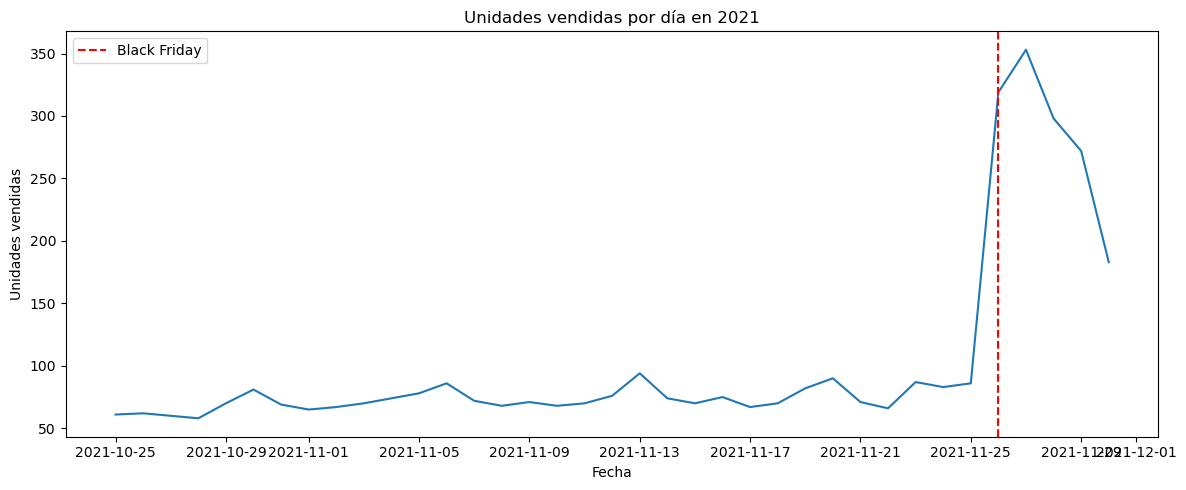

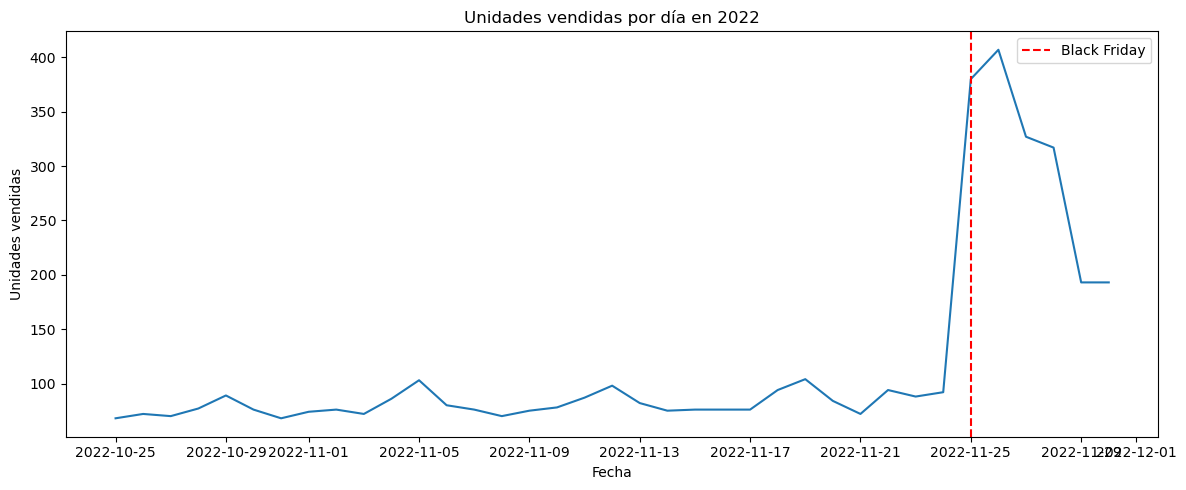

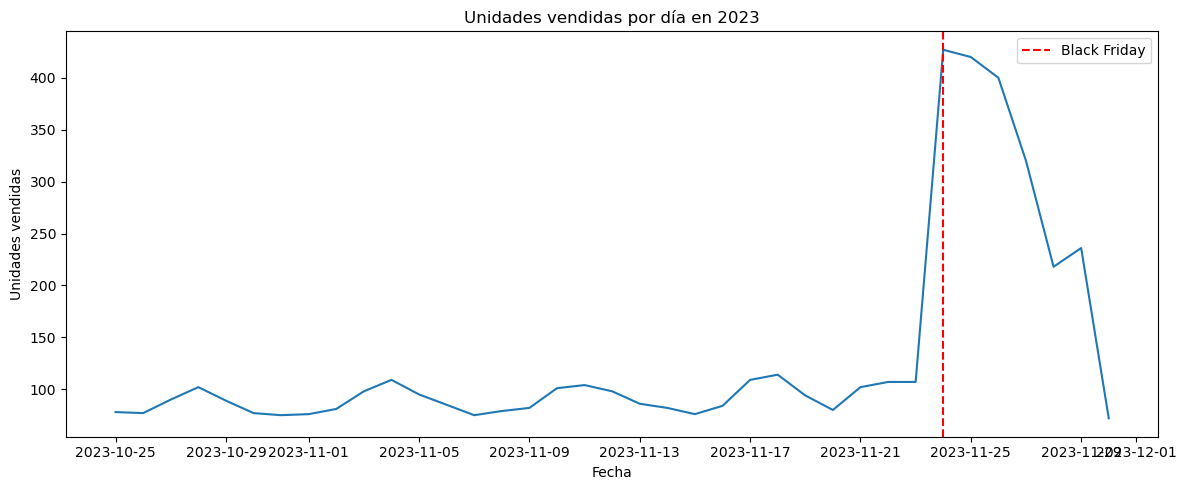

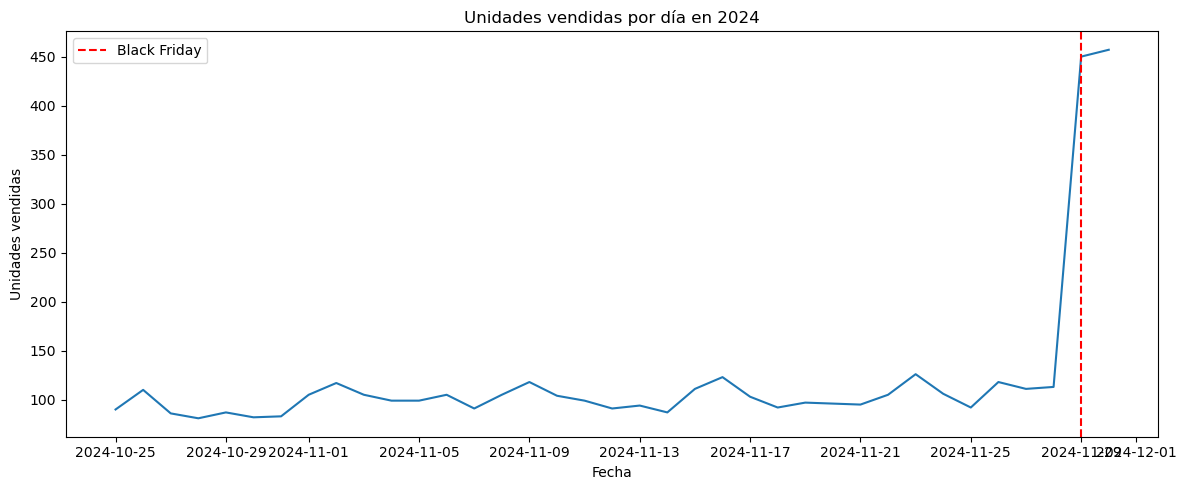

In [16]:
# 🤖 Gráfico de líneas temporales por año de unidades vendidas y Black Fridays
import holidays

# Aseguramos que la columna fecha es datetime
ventas['fecha'] = pd.to_datetime(ventas['fecha'])
ventas['año'] = ventas['fecha'].dt.year
ventas['mes'] = ventas['fecha'].dt.month
ventas['dia'] = ventas['fecha'].dt.day

# Detectar Black Fridays (noviembre, último viernes)
black_fridays = []
for year in ventas['año'].unique():
    nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30')
    viernes = nov[nov.weekday == 4]
    if len(viernes) > 0:
        black_fridays.append(viernes[-1])

# Graficar por año
for year in sorted(ventas['año'].unique()):
    plt.figure(figsize=(12,5))
    data = ventas[ventas['año'] == year].groupby('fecha')['unidades_vendidas'].sum()
    sns.lineplot(x=data.index, y=data.values)
    for bf in black_fridays:
        if bf.year == year:
            plt.axvline(bf, color='red', linestyle='--', label='Black Friday')
    plt.title(f'Unidades vendidas por día en {year}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.tight_layout()
    plt.show()

C:\Users\x\AppData\Local\Temp\ipykernel_23168\832284647.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dia_semana_sum.index, y=dia_semana_sum.values, palette='viridis')


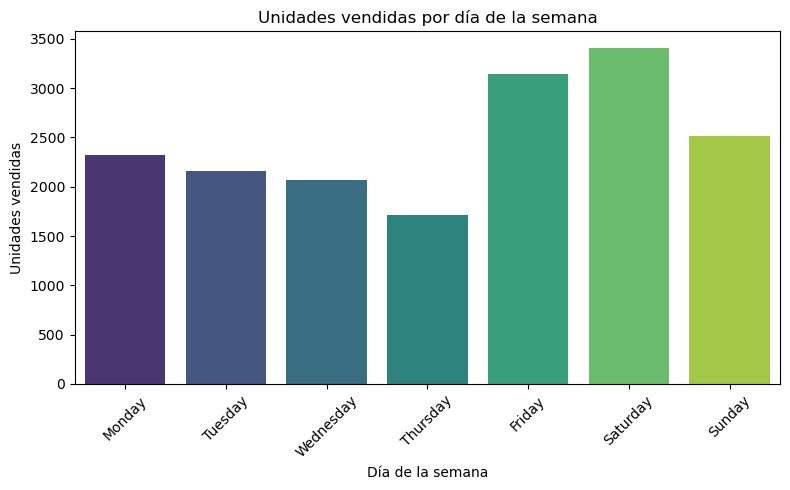

In [17]:
# 🤖 Unidades vendidas por día de la semana
ventas['dia_semana'] = ventas['fecha'].dt.day_name()
dia_semana_sum = ventas.groupby('dia_semana')['unidades_vendidas'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.figure(figsize=(8,5))
sns.barplot(x=dia_semana_sum.index, y=dia_semana_sum.values, palette='viridis')
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\x\AppData\Local\Temp\ipykernel_23168\1384702948.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sum.index, y=cat_sum.values, palette='mako')


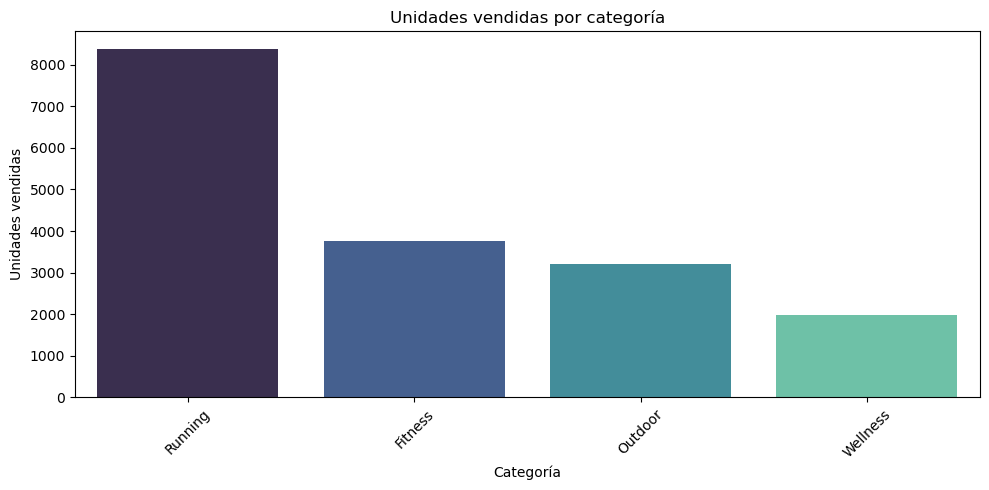

In [18]:
# 🤖 Unidades vendidas por categoría
cat_sum = ventas.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=cat_sum.index, y=cat_sum.values, palette='mako')
plt.title('Unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\x\AppData\Local\Temp\ipykernel_23168\2208782327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_sum.index, y=subcat_sum.values, palette='crest')


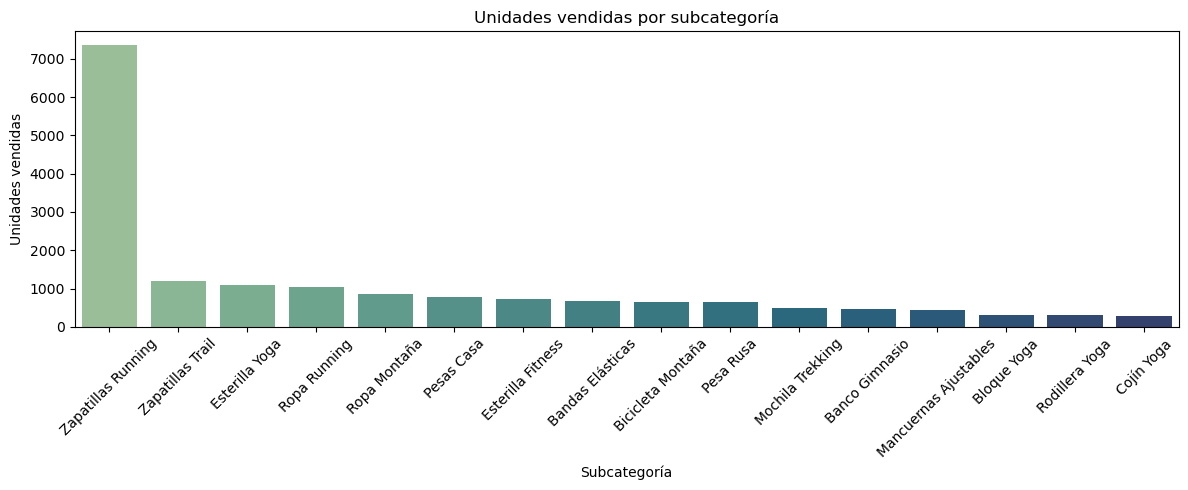

In [19]:
# 🤖 Unidades vendidas por subcategoría
subcat_sum = ventas.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,5))
sns.barplot(x=subcat_sum.index, y=subcat_sum.values, palette='crest')
plt.title('Unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\x\AppData\Local\Temp\ipykernel_23168\1202883489.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_prod.index.get_level_values('nombre'), y=top_prod.values, palette='rocket')


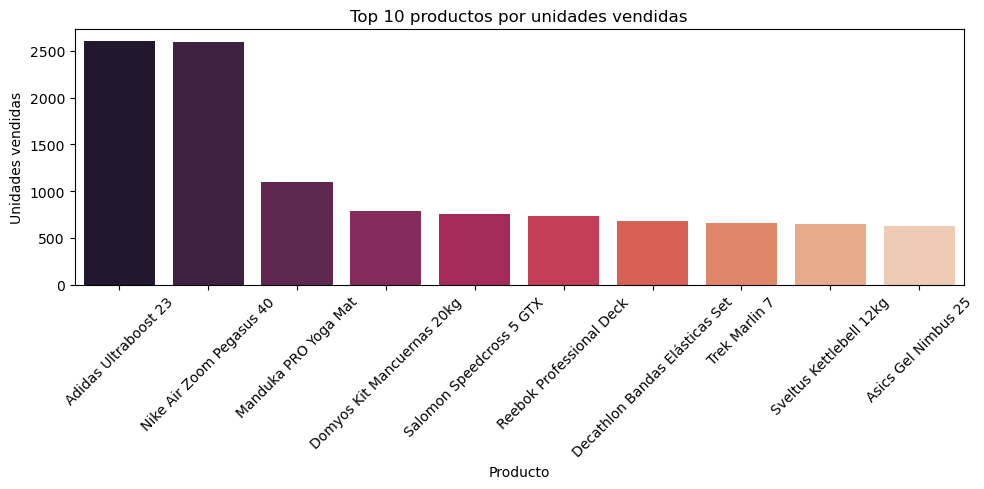

In [20]:
# 🤖 Top productos por unidades vendidas
TOP_N = 10
top_prod = ventas.groupby(['producto_id', 'nombre'])['unidades_vendidas'].sum().sort_values(ascending=False).head(TOP_N)
plt.figure(figsize=(10,5))
sns.barplot(x=top_prod.index.get_level_values('nombre'), y=top_prod.values, palette='rocket')
plt.title(f'Top {TOP_N} productos por unidades vendidas')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

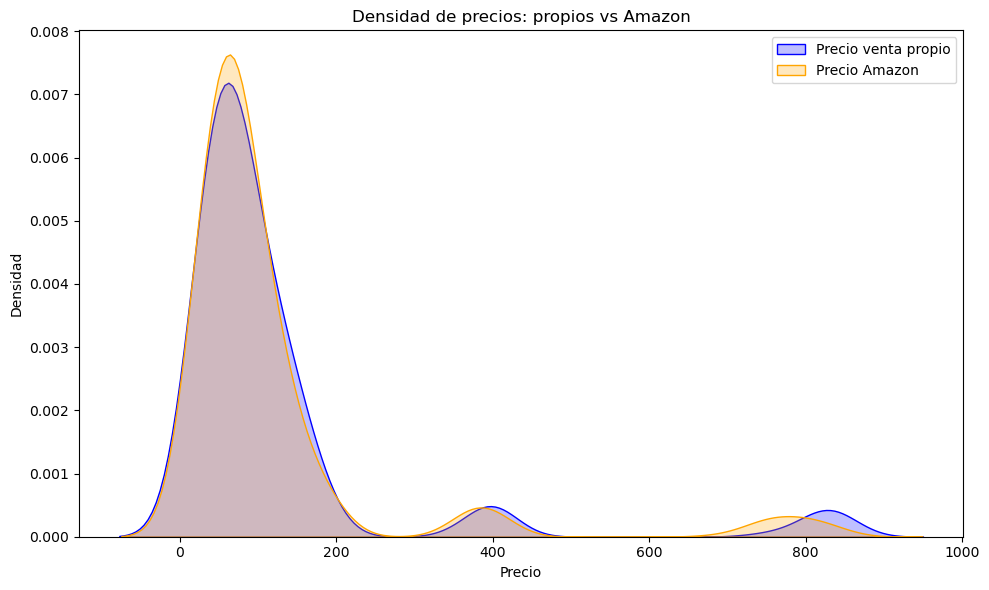

In [21]:
# 🤖 Densidad de precios propios y de Amazon
plt.figure(figsize=(10,6))
sns.kdeplot(ventas['precio_venta'], label='Precio venta propio', fill=True, color='blue')
sns.kdeplot(competencia['Amazon'], label='Precio Amazon', fill=True, color='orange')
plt.title('Densidad de precios: propios vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# 🤖 Creación de variables temporales y de calendario usando Holidays para Argentina
import holidays

# Aseguramos que la columna fecha es datetime
ventas['fecha'] = pd.to_datetime(ventas['fecha'])

# Variables temporales
ventas['año'] = ventas['fecha'].dt.year
ventas['mes'] = ventas['fecha'].dt.month
ventas['dia_mes'] = ventas['fecha'].dt.day
ventas['dia_semana'] = ventas['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
ventas['nombre_dia_semana'] = ventas['fecha'].dt.day_name()
ventas['semana_año'] = ventas['fecha'].dt.isocalendar().week
ventas['trimestre'] = ventas['fecha'].dt.quarter
ventas['es_fin_semana'] = ventas['dia_semana'].isin([5,6])

# Festivos Argentina
ar_holidays = holidays.country_holidays('AR', years=ventas['año'].unique())
ventas['ar_festivo'] = ventas['fecha'].isin(ar_holidays)

# Black Friday (último viernes de noviembre)
def es_black_friday(fecha):
    if fecha.month == 11 and fecha.weekday() == 4:
        # Último viernes de noviembre
        last_friday = max([d for d in pd.date_range(fecha.replace(day=1), fecha.replace(day=30)) if d.weekday() == 4])
        return fecha == last_friday
    return False
ventas['ar_Black_Friday'] = ventas['fecha'].apply(es_black_friday)

# Cyber Monday (primer lunes de noviembre)
def es_cyber_monday(fecha):
    if fecha.month == 11 and fecha.weekday() == 0:
        first_monday = min([d for d in pd.date_range(fecha.replace(day=1), fecha.replace(day=7)) if d.weekday() == 0])
        return fecha == first_monday
    return False
ventas['ar_Cyber_Monday'] = ventas['fecha'].apply(es_cyber_monday)

# Variable de día laborable
ventas['es_laborable'] = (~ventas['es_fin_semana']) & (~ventas['ar_festivo'])

# Variable de mitad de mes
ventas['mitad_mes'] = ventas['dia_mes'].between(10,20)

# Variable de inicio de mes
ventas['inicio_mes'] = ventas['dia_mes'] <= 7

# Variable de fin de mes
ventas['fin_mes'] = ventas['dia_mes'] >= 25

# Mostrar las primeras filas con las nuevas variables
ventas.head()

C:\Users\x\AppData\Local\Temp\ipykernel_23168\2869477194.py:19: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  ventas['ar_festivo'] = ventas['fecha'].isin(ar_holidays)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,semana_año,trimestre,es_fin_semana,ar_festivo,ar_Black_Friday,ar_Cyber_Monday,es_laborable,mitad_mes,inicio_mes,fin_mes
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,43,4,False,False,False,False,True,False,False,True
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,43,4,False,False,False,False,True,False,False,True
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,43,4,False,False,False,False,True,False,False,True
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,43,4,False,False,False,False,True,False,False,True
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,43,4,False,False,False,False,True,False,False,True


In [23]:
df.shape

(3552, 13)

In [24]:
# 🤖 Creación de LAGs y media móvil de 7 días para unidades vendidas (por año)

ventas = ventas.sort_values(['producto_id', 'año', 'fecha'])

# Crear LAGs del 1 al 7 y media móvil de 7 días por producto y año
for lag in range(1, 8):
    ventas[f'unidades_vendidas_lag{lag}'] = ventas.groupby(['producto_id', 'año'])['unidades_vendidas'].shift(lag)

ventas['unidades_vendidas_mm7'] = ventas.groupby(['producto_id', 'año'])['unidades_vendidas'].transform(lambda x: x.rolling(7).mean())

# Eliminar registros con nulos en cualquier LAG o media móvil
lag_cols = [f'unidades_vendidas_lag{i}' for i in range(1,8)] + ['unidades_vendidas_mm7']
ventas = ventas.dropna(subset=lag_cols).reset_index(drop=True)

# Mostrar las primeras filas con los LAGs y media móvil
ventas[[
    'fecha', 'producto_id', 'unidades_vendidas',
    'unidades_vendidas_lag1', 'unidades_vendidas_lag2', 'unidades_vendidas_lag3',
    'unidades_vendidas_lag4', 'unidades_vendidas_lag5', 'unidades_vendidas_lag6',
    'unidades_vendidas_lag7', 'unidades_vendidas_mm7']].head(10)

,fecha,producto_id,unidades_vendidas,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7
0,2021-11-01,PROD_001,7,9.0,12.0,12.0,7.0,8.0,8.0,6.0,9.000000
1,2021-11-02,PROD_001,10,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.285714
2,2021-11-03,PROD_001,11,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.714286
3,2021-11-04,PROD_001,12,11.0,10.0,7.0,9.0,12.0,12.0,7.0,10.428571
4,2021-11-05,PROD_001,10,12.0,11.0,10.0,7.0,9.0,12.0,12.0,10.142857
5,2021-11-06,PROD_001,10,10.0,12.0,11.0,10.0,7.0,9.0,12.0,9.857143
6,2021-11-07,PROD_001,10,10.0,10.0,12.0,11.0,10.0,7.0,9.0,10.000000
7,2021-11-08,PROD_001,9,10.0,10.0,10.0,12.0,11.0,10.0,7.0,10.285714
8,2021-11-09,PROD_001,11,9.0,10.0,10.0,10.0,12.0,11.0,10.0,10.428571
9,2021-11-10,PROD_001,10,11.0,9.0,10.0,10.0,10.0,12.0,11.0,10.285714


In [25]:
# 🤖 Conteo del número de registros por año
year_counts = ventas['año'].value_counts().sort_index()
print('Número de registros por año:')
print(year_counts)
year_counts

Número de registros por año:
año
2021    720
2022    720
2023    720
2024    720
Name: count, dtype: int64


año
2021    720
2022    720
2023    720
2024    720
Name: count, dtype: int64

In [26]:
# 🤖 Variable de descuento porcentaje respecto al precio base
ventas['descuento_porcentaje'] = ((ventas['precio_venta'] - ventas['precio_base']) / ventas['precio_base']) * 100
ventas['descuento_porcentaje'] = ventas['descuento_porcentaje'].round(2)

# Mostrar las primeras filas para verificar
ventas[['fecha', 'producto_id', 'precio_base', 'precio_venta', 'descuento_porcentaje']].head(10)


,fecha,producto_id,precio_base,precio_venta,descuento_porcentaje
0,2021-11-01,PROD_001,115,115.07,0.06
1,2021-11-02,PROD_001,115,116.10,0.96
2,2021-11-03,PROD_001,115,114.58,-0.37
3,2021-11-04,PROD_001,115,112.23,-2.41
4,2021-11-05,PROD_001,115,113.81,-1.03
5,2021-11-06,PROD_001,115,117.80,2.43
6,2021-11-07,PROD_001,115,116.04,0.90
7,2021-11-08,PROD_001,115,113.46,-1.34
8,2021-11-09,PROD_001,115,113.98,-0.89
9,2021-11-10,PROD_001,115,117.57,2.23


In [27]:
# 🤖 Crear variable precio_competencia y ratio_precio, y eliminar columnas de competencia
# Usar el dataframe df, que sí tiene las columnas de competencia
ventas = ventas.merge(df[['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage']], on=['fecha', 'producto_id'], how='left')
ventas['precio_competencia'] = ventas[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)
ventas['ratio_precio'] = ventas['precio_venta'] / ventas['precio_competencia']

# Eliminar columnas de competencia
ventas = ventas.drop(columns=['Amazon', 'Decathlon', 'Deporvillage'])

# Mostrar las primeras filas para verificar
ventas[['fecha', 'producto_id', 'precio_venta', 'precio_competencia', 'ratio_precio']].head(10)

,fecha,producto_id,precio_venta,precio_competencia,ratio_precio
0,2021-11-01,PROD_001,115.07,95.353333,1.206775
1,2021-11-02,PROD_001,116.10,96.153333,1.207446
2,2021-11-03,PROD_001,114.58,95.240000,1.203066
3,2021-11-04,PROD_001,112.23,96.590000,1.161922
4,2021-11-05,PROD_001,113.81,96.170000,1.183425
5,2021-11-06,PROD_001,117.80,95.436667,1.234326
6,2021-11-07,PROD_001,116.04,96.153333,1.206822
7,2021-11-08,PROD_001,113.46,97.003333,1.169651
8,2021-11-09,PROD_001,113.98,96.933333,1.175860
9,2021-11-10,PROD_001,117.57,96.343333,1.220323


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
 10  Amazon             3552 non-null   float64       
 11  Decathlon          3552 non-null   float64       
 12  Deporvillage       3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(5), int64(2), object(4)


In [29]:
# 🤖 Integrar todas las variables nuevas en df
# Hacemos merge de df con ventas para añadir todas las variables nuevas
# (excepto las columnas originales que ya están en df)

# Seleccionamos solo las columnas nuevas de ventas
cols_nuevas = [col for col in ventas.columns if col not in df.columns or col in ['precio_competencia', 'ratio_precio', 'descuento_porcentaje']
               or col.startswith('unidades_vendidas_lag') or col == 'unidades_vendidas_mm7']

df = df.merge(ventas[['fecha', 'producto_id'] + cols_nuevas], on=['fecha', 'producto_id'], how='left')

df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7,descuento_porcentaje,precio_competencia,ratio_precio
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   fecha                   3552 non-null   datetime64[ns]
 1   producto_id             3552 non-null   object        
 2   nombre                  3552 non-null   object        
 3   categoria               3552 non-null   object        
 4   subcategoria            3552 non-null   object        
 5   precio_base             3552 non-null   int64         
 6   es_estrella             3552 non-null   bool          
 7   unidades_vendidas       3552 non-null   int64         
 8   precio_venta            3552 non-null   float64       
 9   ingresos                3552 non-null   float64       
 10  Amazon                  3552 non-null   float64       
 11  Decathlon               3552 non-null   float64       
 12  Deporvillage            3552 non-null   float64 

In [31]:
# 🤖 Copia de variables y One Hot Encoding
# Crear copias con sufijo _h
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

# One Hot Encoding sobre las nuevas variables
one_hot = pd.get_dummies(df[['nombre_h', 'categoria_h', 'subcategoria_h']], prefix=['nombre_h', 'categoria_h', 'subcategoria_h'])
df = pd.concat([df, one_hot], axis=1)

df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,False,False,False,False,False,False,False,False,True,False
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,False,False,False,False,False,False,False,False,True,False
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,False,False,False,False,False,False,False,False,True,False
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,False,False,False,False,False,False,False,False,True,False
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,False,False,False,False,False,False,False,True,False,False


In [32]:
# 🤖 Guardar el dataframe df en la carpeta data/processed
df.to_csv('../data/processed/df.csv', index=False)
print('Archivo guardado en data/processed/df.csv')

Archivo guardado en data/processed/df.csv


In [33]:
# 🤖 División de df en train_df (2021-2023) y validation_df (2024)
train_df = df[df['año'].isin([2021, 2022, 2023])].copy()
validation_df = df[df['año'] == 2024].copy()

print(f'Registros en train_df: {len(train_df)}')
print(f'Registros en validation_df: {len(validation_df)}')

Registros en train_df: 2160
Registros en validation_df: 720


In [34]:
# 🤖 Entrenamiento y validación de HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Selección de variables predictoras
excluir = ['fecha', 'ingresos', 'unidades_vendidas'] + list(train_df.select_dtypes(include=['object']).columns)
X_train = train_df.drop(columns=excluir)
y_train = train_df['unidades_vendidas']
X_val = validation_df.drop(columns=excluir)
y_val = validation_df['unidades_vendidas']

# Modelo con parámetros conservadores
model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    random_state=42
)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_val)

# Baseline naive: predice la media de train
y_pred_naive = np.full_like(y_val, y_train.mean(), dtype=float)

# Métricas
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

mae_naive = mean_absolute_error(y_val, y_pred_naive)
mse_naive = mean_squared_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mse_naive)
r2_naive = r2_score(y_val, y_pred_naive)

print('HistGradientBoostingRegressor:')
print(f'MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}')
print('Baseline Naive:')
print(f'MAE: {mae_naive:.2f}, MSE: {mse_naive:.2f}, RMSE: {rmse_naive:.2f}, R2: {r2_naive:.2f}')

HistGradientBoostingRegressor:
MAE: 0.82, MSE: 2.63, RMSE: 1.62, R2: 0.94
Baseline Naive:
MAE: 3.67, MSE: 44.79, RMSE: 6.69, R2: -0.00


C:\Users\x\AppData\Local\Temp\ipykernel_23168\387204214.py:34: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['ar_festivo'] = df['fecha'].isin(ar_holidays)


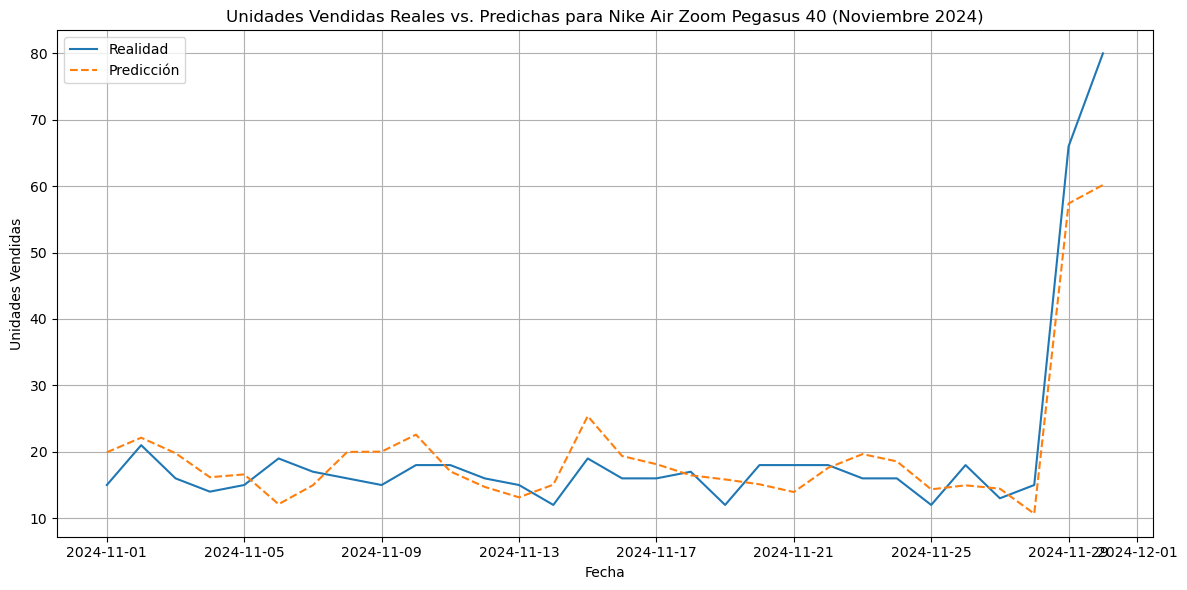

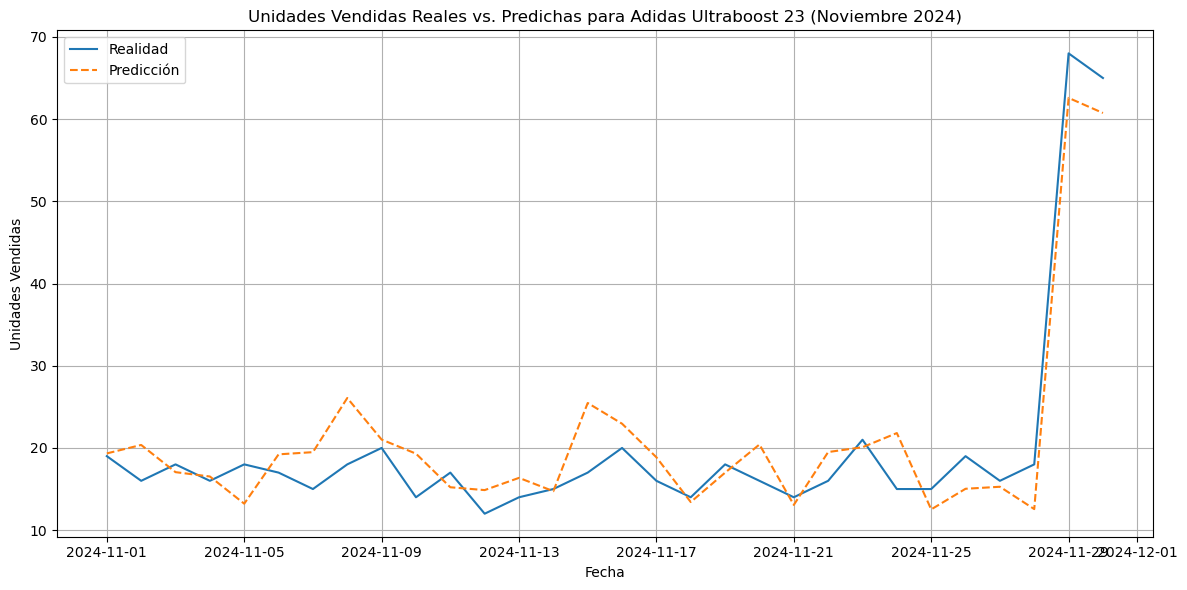

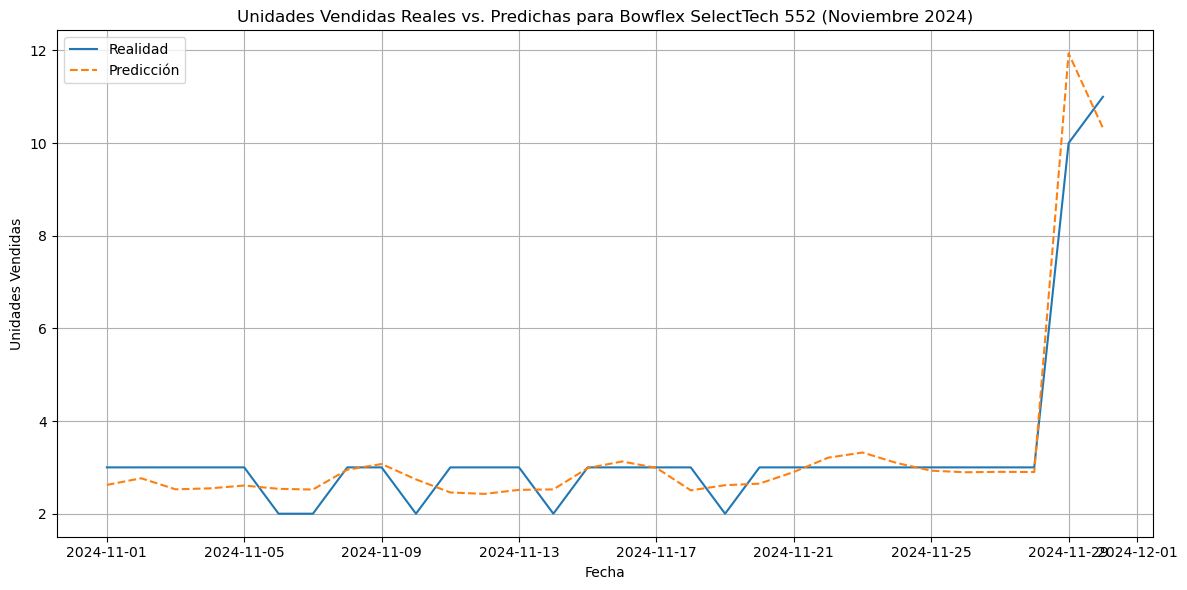

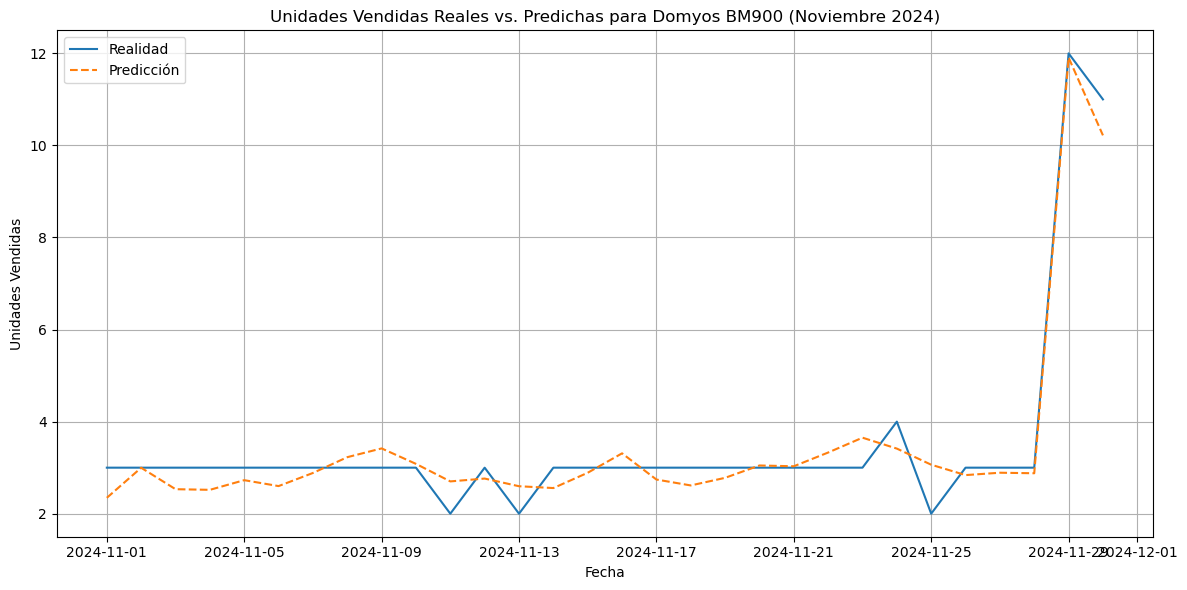

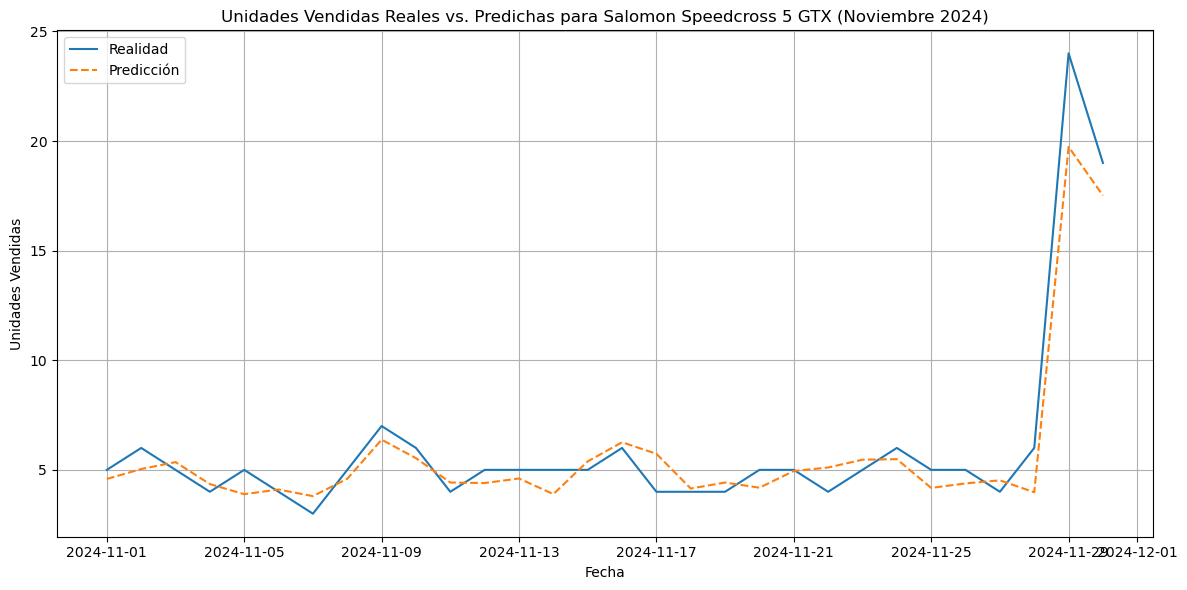

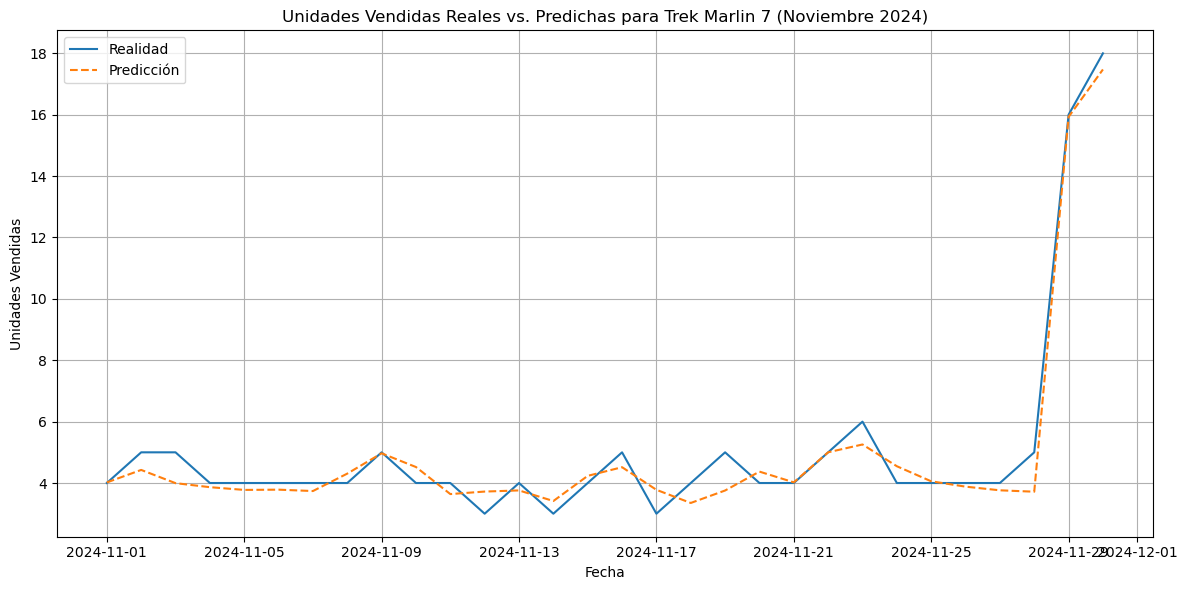

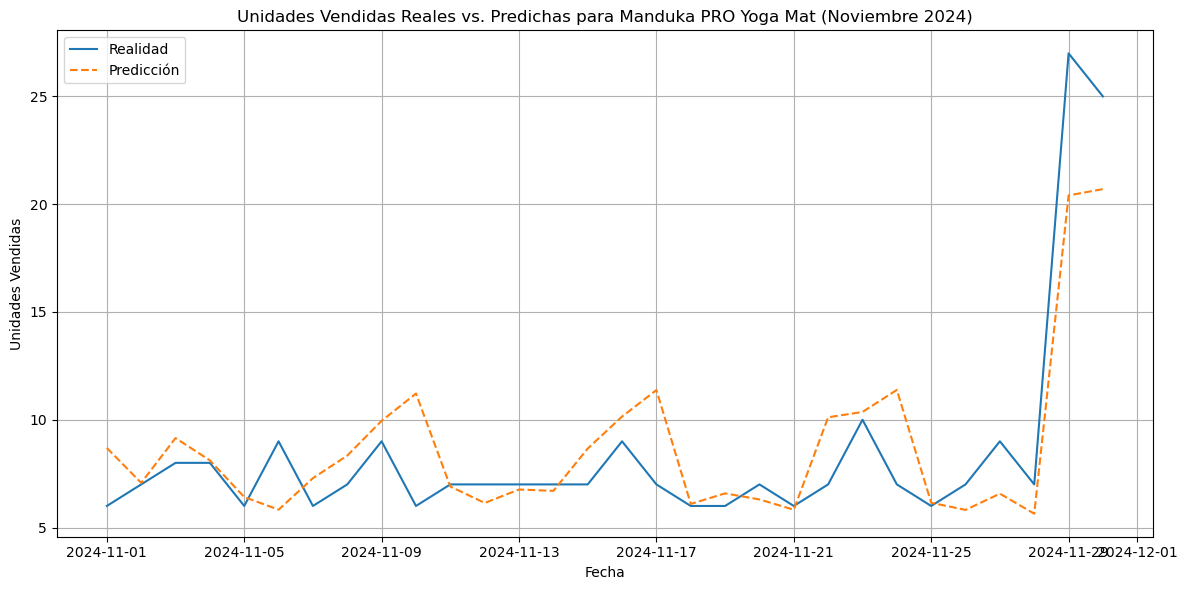

In [35]:
# 🤖 Aplicar el modelo a noviembre de 2024 para productos estrella y graficar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import holidays

# --- Carga y preparación inicial de df (replicado de celdas anteriores) ---
# Cargar los datos de ventas y competencia
ventas = pd.read_csv("../data/raw/entrenamiento/ventas.csv")
competencia = pd.read_csv("../data/raw/entrenamiento/competencia.csv")

# Convertir la columna 'fecha' a datetime en ambos dataframes
ventas['fecha'] = pd.to_datetime(ventas['fecha'])
competencia['fecha'] = pd.to_datetime(competencia['fecha'])

# Integrar ventas y competencia en un solo dataframe
df = pd.merge(ventas, competencia, on=["fecha", "producto_id"], how="inner")

# Creación de variables temporales y de calendario (aplicado directamente a df)
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['nombre_dia_semana'] = df['fecha'].dt.day_name()
df['semana_año'] = df['fecha'].dt.isocalendar().week
df['trimestre'] = df['fecha'].dt.quarter
df['es_fin_semana'] = df['dia_semana'].isin([5,6])

ar_holidays = holidays.country_holidays('AR', years=df['año'].unique())
df['ar_festivo'] = df['fecha'].isin(ar_holidays)

def es_black_friday(fecha):
    if fecha.month == 11 and fecha.weekday() == 4:
        last_friday = max([d for d in pd.date_range(fecha.replace(day=1), fecha.replace(day=30)) if d.weekday() == 4])
        return fecha == last_friday
    return False
df['ar_Black_Friday'] = df['fecha'].apply(es_black_friday)

def es_cyber_monday(fecha):
    if fecha.month == 11 and fecha.weekday() == 0:
        first_monday = min([d for d in pd.date_range(fecha.replace(day=1), fecha.replace(day=7)) if d.weekday() == 0])
        return fecha == first_monday
    return False
df['ar_Cyber_Monday'] = df['fecha'].apply(es_cyber_monday)

df['es_laborable'] = (~df['es_fin_semana']) & (~df['ar_festivo'])
df['mitad_mes'] = df['dia_mes'].between(10,20)
df['inicio_mes'] = df['dia_mes'] <= 7
df['fin_mes'] = df['dia_mes'] >= 25

# Creación de LAGs y media móvil de 7 días para unidades vendidas (por año)
df = df.sort_values(['producto_id', 'año', 'fecha'])
for lag in range(1, 8):
    df[f'unidades_vendidas_lag{lag}'] = df.groupby(['producto_id', 'año'])['unidades_vendidas'].shift(lag)
df['unidades_vendidas_mm7'] = df.groupby(['producto_id', 'año'])['unidades_vendidas'].transform(lambda x: x.rolling(7).mean())
lag_cols = [f'unidades_vendidas_lag{i}' for i in range(1,8)] + ['unidades_vendidas_mm7']
df = df.dropna(subset=lag_cols).reset_index(drop=True)

# Variable de descuento porcentaje respecto al precio base
df['descuento_porcentaje'] = ((df['precio_base'] - df['precio_venta']) / df['precio_base']) * 100
df['descuento_porcentaje'] = df['descuento_porcentaje'].round(2)

# Crear variable precio_competencia y ratio_precio, y eliminar columnas de competencia
df['precio_competencia'] = df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']
df = df.drop(columns=['Amazon', 'Decathlon', 'Deporvillage'])

# Copia de variables y One Hot Encoding
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']
one_hot = pd.get_dummies(df[['nombre_h', 'categoria_h', 'subcategoria_h']], prefix=['nombre_h', 'categoria_h', 'subcategoria_h'])
df = pd.concat([df, one_hot], axis=1)

# --- Fin de carga y preparación inicial de df ---

# 🤖 División de df en train_df (2021-2023) y validation_df (2024)
train_df = df[df['año'].isin([2021, 2022, 2023])].copy()
validation_df = df[df['año'] == 2024].copy()

# Selección de variables predictoras
excluir = ['fecha', 'ingresos', 'unidades_vendidas'] + list(train_df.select_dtypes(include=['object']).columns)
X_train = train_df.drop(columns=excluir)
y_train = train_df['unidades_vendidas']
X_val = validation_df.drop(columns=excluir)
y_val = validation_df['unidades_vendidas']

# Modelo con parámetros conservadores
model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    random_state=42
)
model.fit(X_train, y_train)

# Filtrar datos de noviembre de 2024 y productos estrella
nov_2024_df = validation_df[(validation_df['mes'] == 11) & (validation_df['año'] == 2024) & (validation_df['es_estrella'] == True)].copy()

# Preparar datos para predicción
X_nov_2024 = nov_2024_df.drop(columns=excluir)
y_nov_2024 = nov_2024_df['unidades_vendidas']

# Generar predicciones
y_pred_nov = model.predict(X_nov_2024)

# Añadir predicciones al dataframe de noviembre
nov_2024_df['predicciones'] = y_pred_nov

# Graficar para cada producto estrella
productos_estrella = nov_2024_df['nombre'].unique()

for producto in productos_estrella:
    plt.figure(figsize=(12, 6))
    data_producto = nov_2024_df[nov_2024_df['nombre'] == producto].sort_values('fecha')
    
    sns.lineplot(x='fecha', y='unidades_vendidas', data=data_producto, label='Realidad')
    sns.lineplot(x='fecha', y='predicciones', data=data_producto, label='Predicción', linestyle='--')
    
    plt.title(f'Unidades Vendidas Reales vs. Predichas para {producto} (Noviembre 2024)')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades Vendidas')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [36]:
# 🤖 Cálculo del MAE para productos estrella en el conjunto de validación (2024)
from sklearn.metrics import mean_absolute_error

# Primero, crear el dataset de noviembre 2024 desde validation_df
noviembre_2024 = validation_df[validation_df['mes'] == 11].copy()

# Definir productos estrella
productos_estrella = noviembre_2024[noviembre_2024['es_estrella'] == True]['producto_id'].unique()

mae_productos = {}
for producto_id in productos_estrella:
    df_prod = noviembre_2024[noviembre_2024['producto_id'] == producto_id].copy()
    nombre_prod = df_prod['nombre'].iloc[0]
    excluir = ['fecha', 'ingresos', 'unidades_vendidas', 'nombre', 'producto_id', 'categoria', 'subcategoria']
    x_prod = df_prod.drop(columns=[col for col in excluir if col in df_prod.columns] + [col for col in df_prod.columns if df_prod[col].dtypes == 'object'])
    y_real = df_prod['unidades_vendidas']
    y_pred = model.predict(x_prod)
    mae = mean_absolute_error(y_real, y_pred)
    mae_productos[nombre_prod] = mae

print('MAE por producto estrella en noviembre 2024: ')
for nombre, mae in mae_productos.items():
    print(f'{nombre}: {mae:.2f}')


MAE por producto estrella en noviembre 2024: 
Nike Air Zoom Pegasus 40: 3.76
Adidas Ultraboost 23: 3.13
Bowflex SelectTech 552: 0.38
Domyos BM900: 0.35
Salomon Speedcross 5 GTX: 0.79
Trek Marlin 7: 0.41
Manduka PRO Yoga Mat: 1.68



MÉTRICAS DE ERROR POR PERÍODO - NOVIEMBRE 2024
   Periodo      MAE     RMSE       R²  N_observaciones
 Días 1-10 0.690827 1.328472 0.891554              240
Días 11-20 0.614243 1.114586 0.915164              240
Días 21-30 1.029927 2.043529 0.956883              240

DEGRADACIÓN DEL ERROR (% cambio respecto al primer período)
   Periodo      MAE  Degradación_MAE_%
 Días 1-10 0.690827               0.00
Días 11-20 0.614243             -11.09
Días 21-30 1.029927              49.09


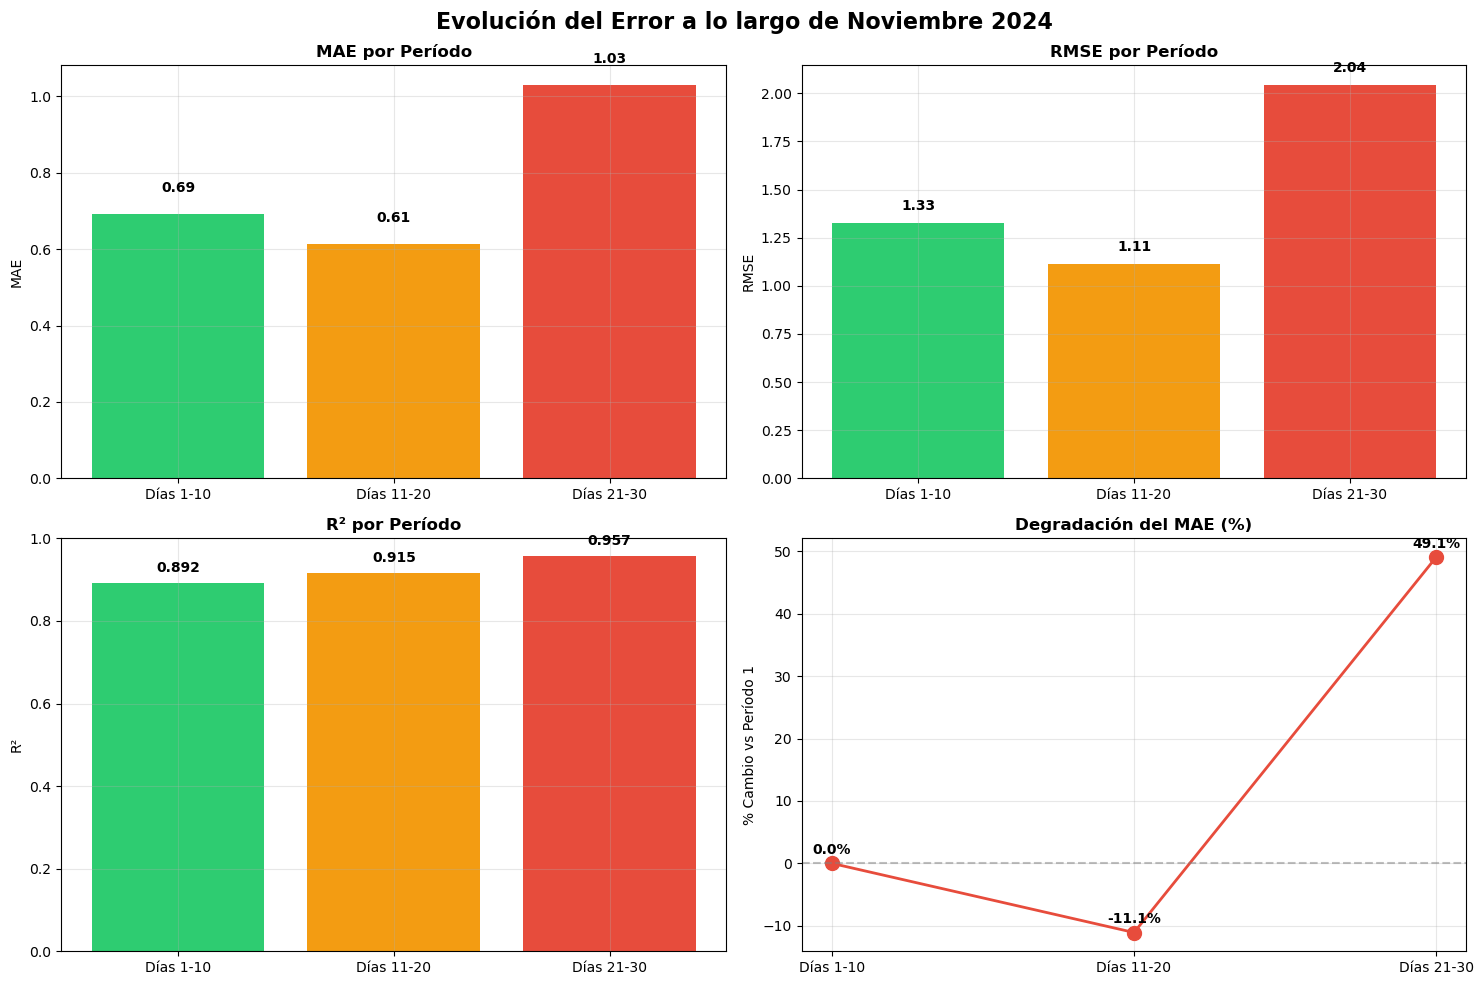

C:\Users\x\AppData\Local\Temp\ipykernel_23168\534240046.py:109: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_por_dia = noviembre_2024.groupby('dia').apply(


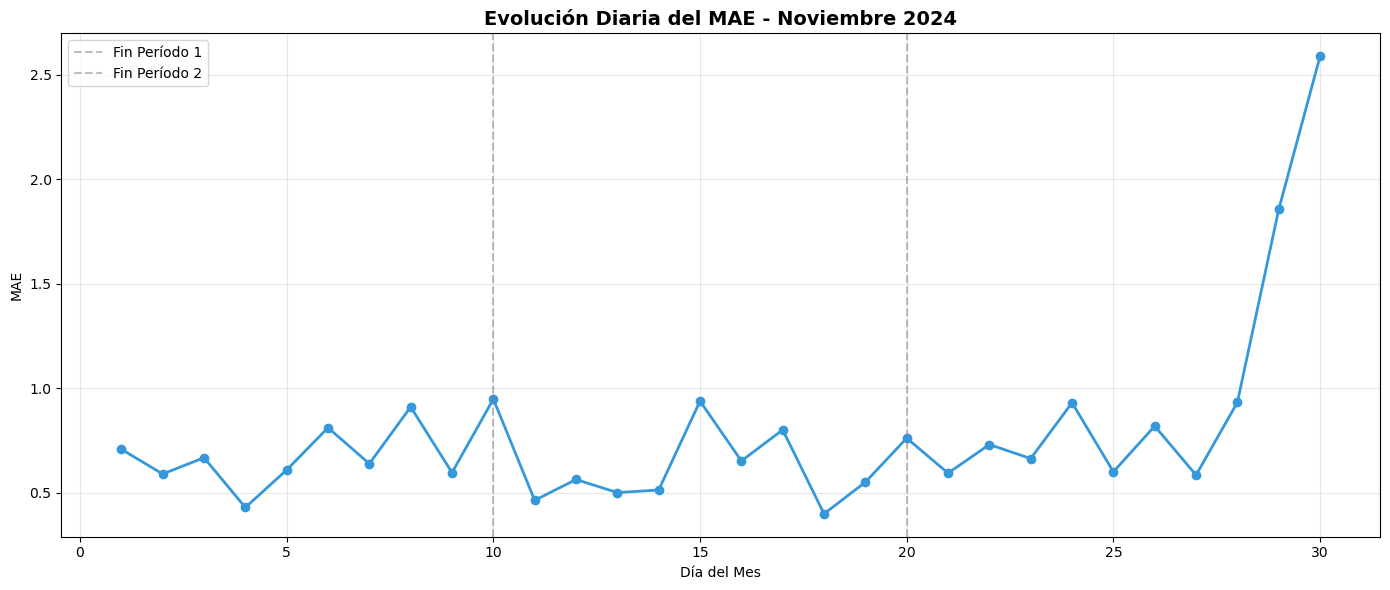


✅ Análisis completado


In [37]:
# 🤖 Análisis de degradación del error a lo largo de noviembre 2024
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definir los 3 períodos de 10 días
noviembre_2024['periodo'] = pd.cut(
    noviembre_2024['fecha'].dt.day,
    bins=[0, 10, 20, 30],
    labels=['Días 1-10', 'Días 11-20', 'Días 21-30']
)

# Preparar datos para predicción
excluir = ['fecha', 'ingresos', 'unidades_vendidas', 'nombre', 'producto_id', 'categoria', 'subcategoria', 'periodo']
X_nov = noviembre_2024.drop(columns=[col for col in excluir if col in noviembre_2024.columns] + 
                              [col for col in noviembre_2024.columns if noviembre_2024[col].dtypes == 'object'])
y_nov = noviembre_2024['unidades_vendidas']

# Generar predicciones
noviembre_2024['predicciones'] = model.predict(X_nov)

# Calcular métricas por período
metricas_por_periodo = []

for periodo in ['Días 1-10', 'Días 11-20', 'Días 21-30']:
    df_periodo = noviembre_2024[noviembre_2024['periodo'] == periodo]
    
    y_real = df_periodo['unidades_vendidas']
    y_pred = df_periodo['predicciones']
    
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    
    metricas_por_periodo.append({
        'Periodo': periodo,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'N_observaciones': len(df_periodo)
    })

# Crear DataFrame con métricas
df_metricas = pd.DataFrame(metricas_por_periodo)

# Mostrar tabla de métricas
print("\n" + "="*70)
print("MÉTRICAS DE ERROR POR PERÍODO - NOVIEMBRE 2024")
print("="*70)
print(df_metricas.to_string(index=False))
print("="*70)

# Calcular degradación (cambio porcentual respecto al primer período)
mae_inicial = df_metricas.iloc[0]['MAE']
df_metricas['Degradación_MAE_%'] = ((df_metricas['MAE'] - mae_inicial) / mae_inicial * 100).round(2)

print("\n" + "="*70)
print("DEGRADACIÓN DEL ERROR (% cambio respecto al primer período)")
print("="*70)
print(df_metricas[['Periodo', 'MAE', 'Degradación_MAE_%']].to_string(index=False))
print("="*70)

# Crear visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Evolución del Error a lo largo de Noviembre 2024', fontsize=16, fontweight='bold')

# Gráfico 1: MAE por período
axes[0, 0].bar(df_metricas['Periodo'], df_metricas['MAE'], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0, 0].set_title('MAE por Período', fontweight='bold')
axes[0, 0].set_ylabel('MAE')
axes[0, 0].grid(True, alpha=0.3)
for i, v in enumerate(df_metricas['MAE']):
    axes[0, 0].text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: RMSE por período
axes[0, 1].bar(df_metricas['Periodo'], df_metricas['RMSE'], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0, 1].set_title('RMSE por Período', fontweight='bold')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].grid(True, alpha=0.3)
for i, v in enumerate(df_metricas['RMSE']):
    axes[0, 1].text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 3: R² por período
axes[1, 0].bar(df_metricas['Periodo'], df_metricas['R²'], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1, 0].set_title('R² por Período', fontweight='bold')
axes[1, 0].set_ylabel('R²')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(True, alpha=0.3)
for i, v in enumerate(df_metricas['R²']):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 4: Degradación del MAE
axes[1, 1].plot(df_metricas['Periodo'], df_metricas['Degradación_MAE_%'], 
                marker='o', linewidth=2, markersize=10, color='#e74c3c')
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Degradación del MAE (%)', fontweight='bold')
axes[1, 1].set_ylabel('% Cambio vs Período 1')
axes[1, 1].grid(True, alpha=0.3)
for i, v in enumerate(df_metricas['Degradación_MAE_%']):
    axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis adicional: Error por día
noviembre_2024['dia'] = noviembre_2024['fecha'].dt.day
error_por_dia = noviembre_2024.groupby('dia').apply(
    lambda x: mean_absolute_error(x['unidades_vendidas'], x['predicciones'])
).reset_index()
error_por_dia.columns = ['dia', 'MAE']

# Gráfico de evolución diaria del error
plt.figure(figsize=(14, 6))
plt.plot(error_por_dia['dia'], error_por_dia['MAE'], marker='o', linewidth=2, markersize=6, color='#3498db')
plt.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='Fin Período 1')
plt.axvline(x=20, color='gray', linestyle='--', alpha=0.5, label='Fin Período 2')
plt.title('Evolución Diaria del MAE - Noviembre 2024', fontsize=14, fontweight='bold')
plt.xlabel('Día del Mes')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ Análisis completado")


✅ Datos encontrados para Black Friday 2024: 24 productos

ANÁLISIS BLACK FRIDAY 2024 - RESUMEN GENERAL
Fecha: 2024-11-29
Total de productos: 24
MAE General: 1.86 unidades
MAPE General: 8.90%
Total Real: 450 unidades
Total Predicho: 424 unidades

📊 TOP 5 PRODUCTOS CON MAYOR ERROR ABSOLUTO:
producto_id                    nombre  unidades_vendidas  predicciones  error_absoluto
   PROD_001  Nike Air Zoom Pegasus 40                 66     57.393521        8.606479
   PROD_021      Manduka PRO Yoga Mat                 27     20.409558        6.590442
   PROD_002      Adidas Ultraboost 23                 68     62.580697        5.419303
   PROD_015  Salomon Speedcross 5 GTX                 24     19.733904        4.266096
   PROD_006 Adidas Own The Run Jacket                 12     15.081532        3.081532


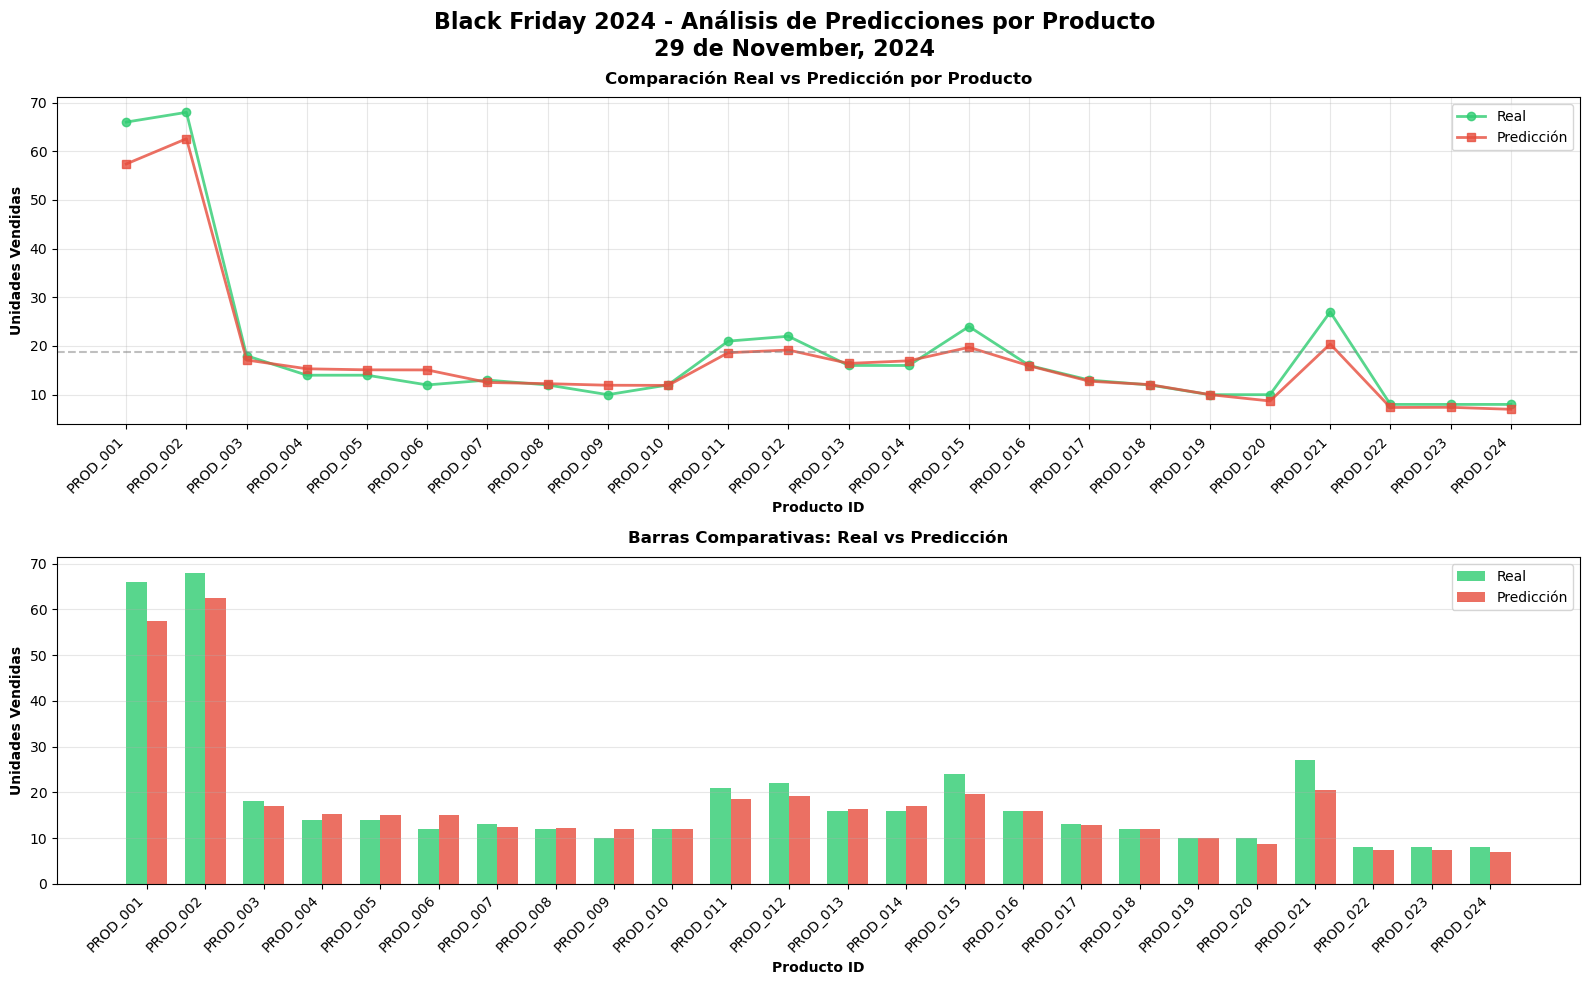

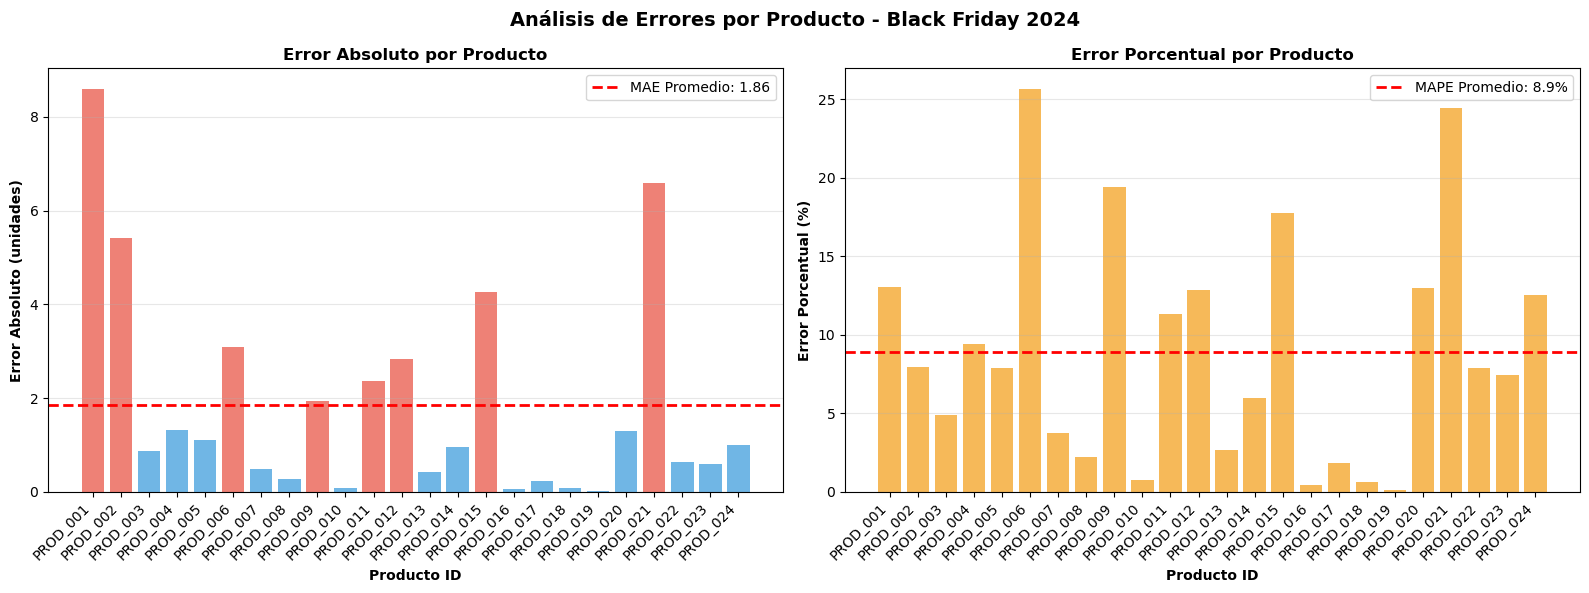


ANÁLISIS POR TIPO DE PRODUCTO

Productos Estrella:
  - Cantidad: 7 productos
  - MAE: 3.85 unidades
  - Total Real: 223 unidades
  - Total Predicho: 200 unidades

Productos Regulares:
  - Cantidad: 17 productos
  - MAE: 1.03 unidades
  - Total Real: 227 unidades
  - Total Predicho: 224 unidades

✅ Análisis de Black Friday completado


In [38]:
# 🤖 Análisis Black Friday 2024 - Real vs Predicho por Producto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Identificar el Black Friday 2024 (último viernes de noviembre)
# En 2024, el Black Friday es el 29 de noviembre
black_friday_2024 = pd.Timestamp('2024-11-29')

# Filtrar datos del Black Friday
df_black_friday = noviembre_2024[noviembre_2024['fecha'] == black_friday_2024].copy()

# Verificar si hay datos
if len(df_black_friday) == 0:
    print("⚠️ No hay datos para el Black Friday 2024 (29 de noviembre)")
    print("Buscando datos disponibles en noviembre...")
    print(f"Fechas disponibles: {sorted(noviembre_2024['fecha'].unique())}")
else:
    print(f"✅ Datos encontrados para Black Friday 2024: {len(df_black_friday)} productos")
    
    # Preparar datos para análisis
    df_black_friday = df_black_friday.sort_values('producto_id')
    
    # Calcular métricas generales
    mae_total = mean_absolute_error(df_black_friday['unidades_vendidas'], 
                                     df_black_friday['predicciones'])
    mape_total = mean_absolute_percentage_error(df_black_friday['unidades_vendidas'], 
                                                  df_black_friday['predicciones']) * 100
    
    # Calcular error por producto
    df_black_friday['error_absoluto'] = abs(df_black_friday['unidades_vendidas'] - 
                                             df_black_friday['predicciones'])
    df_black_friday['error_porcentual'] = (df_black_friday['error_absoluto'] / 
                                            df_black_friday['unidades_vendidas'] * 100)
    
    # Mostrar resumen
    print("\n" + "="*80)
    print("ANÁLISIS BLACK FRIDAY 2024 - RESUMEN GENERAL")
    print("="*80)
    print(f"Fecha: {black_friday_2024.strftime('%Y-%m-%d')}")
    print(f"Total de productos: {len(df_black_friday)}")
    print(f"MAE General: {mae_total:.2f} unidades")
    print(f"MAPE General: {mape_total:.2f}%")
    print(f"Total Real: {df_black_friday['unidades_vendidas'].sum():.0f} unidades")
    print(f"Total Predicho: {df_black_friday['predicciones'].sum():.0f} unidades")
    print("="*80)
    
    # Top 5 productos con mayor error
    top_errores = df_black_friday.nlargest(5, 'error_absoluto')[
        ['producto_id', 'nombre', 'unidades_vendidas', 'predicciones', 'error_absoluto']
    ]
    print("\n📊 TOP 5 PRODUCTOS CON MAYOR ERROR ABSOLUTO:")
    print(top_errores.to_string(index=False))
    
    # Crear visualización principal: Real vs Predicho por Producto
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle(f'Black Friday 2024 - Análisis de Predicciones por Producto\n{black_friday_2024.strftime("%d de %B, %Y")}', 
                 fontsize=16, fontweight='bold')
    
    # Gráfico 1: Líneas de Real vs Predicho
    x_pos = np.arange(len(df_black_friday))
    
    axes[0].plot(x_pos, df_black_friday['unidades_vendidas'], 
                 marker='o', linewidth=2, markersize=6, label='Real', color='#2ecc71', alpha=0.8)
    axes[0].plot(x_pos, df_black_friday['predicciones'], 
                 marker='s', linewidth=2, markersize=6, label='Predicción', color='#e74c3c', alpha=0.8)
    
    axes[0].set_xlabel('Producto ID', fontweight='bold')
    axes[0].set_ylabel('Unidades Vendidas', fontweight='bold')
    axes[0].set_title('Comparación Real vs Predicción por Producto', fontweight='bold', pad=10)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(df_black_friday['producto_id'], rotation=45, ha='right')
    axes[0].legend(loc='upper right', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Añadir línea de referencia
    axes[0].axhline(y=df_black_friday['unidades_vendidas'].mean(), 
                    color='gray', linestyle='--', alpha=0.5, label='Media Real')
    
    # Gráfico 2: Barras agrupadas para mejor comparación
    width = 0.35
    axes[1].bar(x_pos - width/2, df_black_friday['unidades_vendidas'], 
                width, label='Real', color='#2ecc71', alpha=0.8)
    axes[1].bar(x_pos + width/2, df_black_friday['predicciones'], 
                width, label='Predicción', color='#e74c3c', alpha=0.8)
    
    axes[1].set_xlabel('Producto ID', fontweight='bold')
    axes[1].set_ylabel('Unidades Vendidas', fontweight='bold')
    axes[1].set_title('Barras Comparativas: Real vs Predicción', fontweight='bold', pad=10)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(df_black_friday['producto_id'], rotation=45, ha='right')
    axes[1].legend(loc='upper right', fontsize=10)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Gráfico adicional: Error por producto
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Análisis de Errores por Producto - Black Friday 2024', 
                 fontsize=14, fontweight='bold')
    
    # Error absoluto
    colors = ['#e74c3c' if e > mae_total else '#3498db' for e in df_black_friday['error_absoluto']]
    axes[0].bar(x_pos, df_black_friday['error_absoluto'], color=colors, alpha=0.7)
    axes[0].axhline(y=mae_total, color='red', linestyle='--', linewidth=2, 
                    label=f'MAE Promedio: {mae_total:.2f}')
    axes[0].set_xlabel('Producto ID', fontweight='bold')
    axes[0].set_ylabel('Error Absoluto (unidades)', fontweight='bold')
    axes[0].set_title('Error Absoluto por Producto', fontweight='bold')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(df_black_friday['producto_id'], rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Error porcentual
    axes[1].bar(x_pos, df_black_friday['error_porcentual'], color='#f39c12', alpha=0.7)
    axes[1].axhline(y=mape_total, color='red', linestyle='--', linewidth=2, 
                    label=f'MAPE Promedio: {mape_total:.1f}%')
    axes[1].set_xlabel('Producto ID', fontweight='bold')
    axes[1].set_ylabel('Error Porcentual (%)', fontweight='bold')
    axes[1].set_title('Error Porcentual por Producto', fontweight='bold')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(df_black_friday['producto_id'], rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Análisis por categoría de producto
    if 'es_estrella' in df_black_friday.columns:
        print("\n" + "="*80)
        print("ANÁLISIS POR TIPO DE PRODUCTO")
        print("="*80)
        
        for es_estrella in [True, False]:
            tipo = "Productos Estrella" if es_estrella else "Productos Regulares"
            df_tipo = df_black_friday[df_black_friday['es_estrella'] == es_estrella]
            
            if len(df_tipo) > 0:
                mae_tipo = mean_absolute_error(df_tipo['unidades_vendidas'], 
                                                df_tipo['predicciones'])
                print(f"\n{tipo}:")
                print(f"  - Cantidad: {len(df_tipo)} productos")
                print(f"  - MAE: {mae_tipo:.2f} unidades")
                print(f"  - Total Real: {df_tipo['unidades_vendidas'].sum():.0f} unidades")
                print(f"  - Total Predicho: {df_tipo['predicciones'].sum():.0f} unidades")
        
        print("="*80)
    
    print("\n✅ Análisis de Black Friday completado")


In [40]:
# 🤖 Reentrenamiento del Modelo Final con Todos los Datos Históricos (2021-2024)
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("="*80)
print("REENTRENAMIENTO DEL MODELO FINAL")
print("="*80)

# Usar el DataFrame completo (df) que contiene datos de 2021 a 2024
print(f"\n📊 Datos disponibles:")
print(f"   - Total de registros: {len(df)}")
print(f"   - Años incluidos: {sorted(df['año'].unique())}")
print(f"   - Rango de fechas: {df['fecha'].min()} a {df['fecha'].max()}")

# Preparar datos para entrenamiento (usando todo el dataset)
print("\n🔧 Preparando datos de entrenamiento...")

# Selección de variables predictoras (excluir las mismas columnas que antes)
excluir = ['fecha', 'ingresos', 'unidades_vendidas'] + list(df.select_dtypes(include=['object']).columns)
X_full = df.drop(columns=excluir)
y_full = df['unidades_vendidas']

print(f"   - Variables predictoras: {X_full.shape[1]}")
print(f"   - Observaciones de entrenamiento: {len(X_full)}")

# Entrenar el modelo con los mismos parámetros óptimos que se usaron anteriormente
print("\n🚀 Entrenando HistGradientBoostingRegressor...")
print("   Parámetros:")
print("   - learning_rate: 0.03")
print("   - max_iter: 400")
print("   - max_depth: 7")
print("   - l2_regularization: 1.0")
print("   - random_state: 42")

model_final = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    random_state=42
)

# Entrenar el modelo
model_final.fit(X_full, y_full)

print("\n✅ Modelo entrenado exitosamente!")

# Evaluar el modelo en el conjunto completo (para ver el ajuste)
print("\n📈 Evaluación del modelo en el conjunto completo:")
y_pred_full = model_final.predict(X_full)

mae_full = mean_absolute_error(y_full, y_pred_full)
mse_full = mean_squared_error(y_full, y_pred_full)
rmse_full = np.sqrt(mse_full)
r2_full = r2_score(y_full, y_pred_full)

print(f"   - MAE:  {mae_full:.2f}")
print(f"   - MSE:  {mse_full:.2f}")
print(f"   - RMSE: {rmse_full:.2f}")
print(f"   - R²:   {r2_full:.4f}")

# Comparación con el modelo anterior (si existe)
if 'model' in locals() or 'model' in globals():
    print("\n📊 Comparación con modelo anterior (entrenado solo con 2021-2023):")
    try:
        print(f"   Modelo anterior - R² en validación: {r2:.4f}")
        print(f"   Modelo final    - R² en datos completos: {r2_full:.4f}")
    except:
        print("   (No se pudo comparar con el modelo anterior)")

# Análisis por año
print("\n📅 Desempeño del modelo final por año:")
print("-" * 80)
for año in sorted(df['año'].unique()):
    df_año = df[df['año'] == año]
    X_año = df_año.drop(columns=excluir)
    y_año = df_año['unidades_vendidas']
    y_pred_año = model_final.predict(X_año)
    
    mae_año = mean_absolute_error(y_año, y_pred_año)
    r2_año = r2_score(y_año, y_pred_año)
    
    print(f"   {año}: MAE = {mae_año:.2f}, R² = {r2_año:.4f}, N = {len(df_año)}")

print("-" * 80)

# Información sobre las variables utilizadas
print("\n📋 Variables utilizadas en el modelo:")
print(f"   Total de variables: {len(X_full.columns)}")
print("\n   Primeras 20 variables:")
for i, col in enumerate(X_full.columns[:20], 1):
    print(f"   {i:2d}. {col}")
if len(X_full.columns) > 20:
    print(f"   ... y {len(X_full.columns) - 20} variables más")

# Guardar el modelo final (opcional - comentado por defecto)
# import joblib
# joblib.dump(model_final, '../models/modelo_final_2021_2024.pkl')
# print("\n💾 Modelo guardado en: ../models/modelo_final_2021_2024.pkl")

print("\n" + "="*80)
print("✅ REENTRENAMIENTO COMPLETADO")
print("="*80)
print("\n📝 Resumen:")
print(f"   - Modelo: HistGradientBoostingRegressor")
print(f"   - Datos de entrenamiento: 2021-2024 ({len(df)} observaciones)")
print(f"   - Variables predictoras: {X_full.shape[1]}")
print(f"   - MAE general: {mae_full:.2f}")
print(f"   - R² general: {r2_full:.4f}")
print("\n   El modelo 'model_final' está listo para hacer predicciones!")
print("="*80)


REENTRENAMIENTO DEL MODELO FINAL

📊 Datos disponibles:
   - Total de registros: 2880
   - Años incluidos: [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
   - Rango de fechas: 2021-11-01 00:00:00 a 2024-11-30 00:00:00

🔧 Preparando datos de entrenamiento...
   - Variables predictoras: 72
   - Observaciones de entrenamiento: 2880

🚀 Entrenando HistGradientBoostingRegressor...
   Parámetros:
   - learning_rate: 0.03
   - max_iter: 400
   - max_depth: 7
   - l2_regularization: 1.0
   - random_state: 42

✅ Modelo entrenado exitosamente!

📈 Evaluación del modelo en el conjunto completo:
   - MAE:  0.51
   - MSE:  1.12
   - RMSE: 1.06
   - R²:   0.9759

📊 Comparación con modelo anterior (entrenado solo con 2021-2023):
   Modelo anterior - R² en validación: 0.9569
   Modelo final    - R² en datos completos: 0.9759

📅 Desempeño del modelo final por año:
--------------------------------------------------------------------------------
   2021: MAE = 0.43, R² = 0.9769, N = 720
  

ANÁLISIS DE IMPORTANCIA DE VARIABLES - PERMUTATION IMPORTANCE

🔍 Calculando Permutation Importance...
   (Esto puede tomar unos minutos dependiendo del tamaño del dataset)
✅ Cálculo completado!

📊 Top 20 Variables Más Importantes:
--------------------------------------------------------------------------------
   unidades_vendidas_mm7                        :   1.3244 (+/- 0.0166)
   descuento_porcentaje                         :   0.1489 (+/- 0.0060)
   unidades_vendidas_lag1                       :   0.0461 (+/- 0.0008)
   unidades_vendidas_lag2                       :   0.0316 (+/- 0.0007)
   unidades_vendidas_lag7                       :   0.0259 (+/- 0.0013)
   ar_Black_Friday                              :   0.0218 (+/- 0.0010)
   dia_semana                                   :   0.0190 (+/- 0.0009)
   precio_competencia                           :   0.0160 (+/- 0.0017)
   unidades_vendidas_lag4                       :   0.0158 (+/- 0.0007)
   unidades_vendidas_lag3               

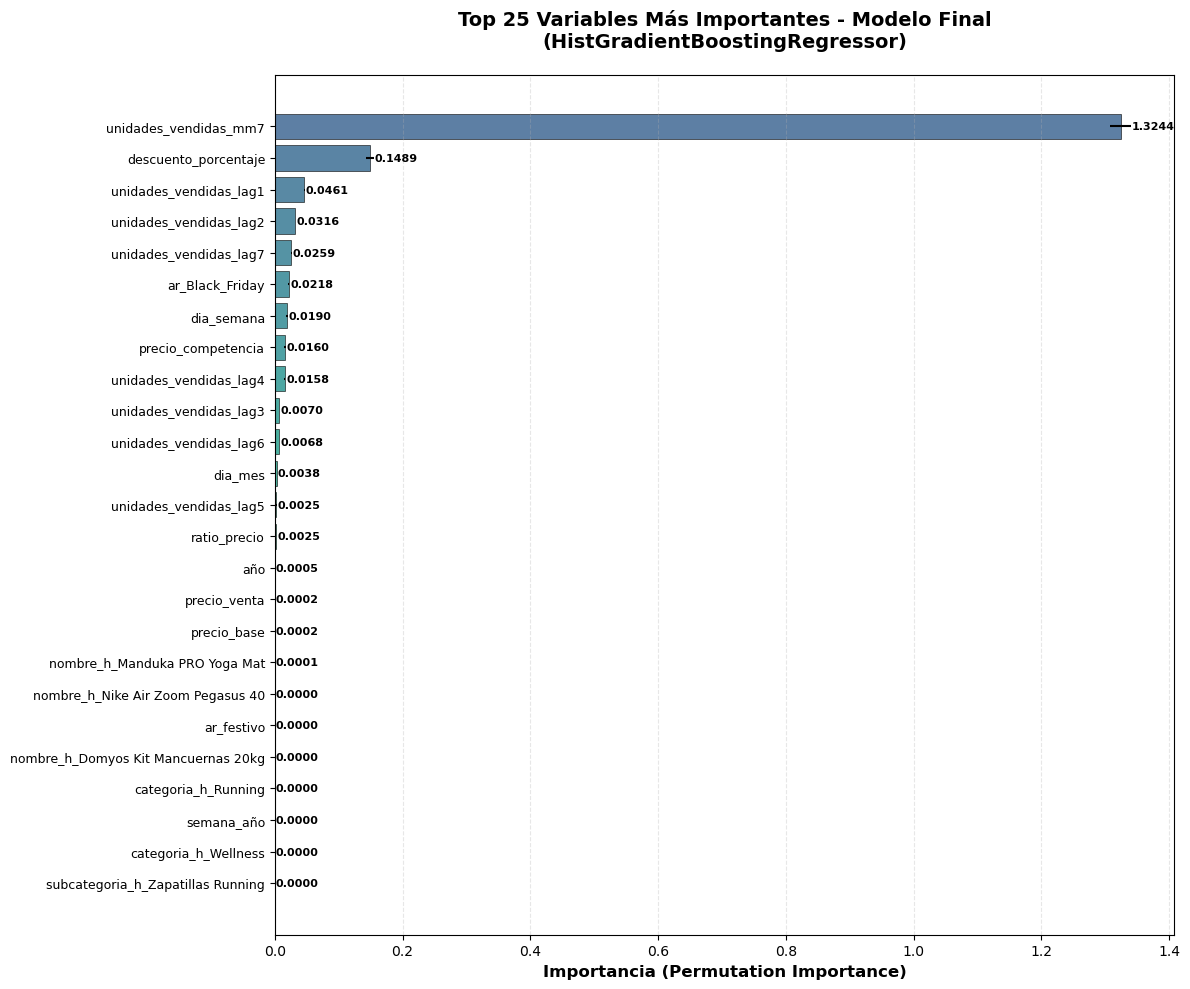


📊 Estadísticas de Importancia:
--------------------------------------------------------------------------------
   Total de variables: 72
   Variables con importancia > 0: 36
   Variables con importancia > 0.001: 14
   Variables con importancia > 0.01: 9
   Importancia máxima: 1.3244
   Importancia media: 0.0232
--------------------------------------------------------------------------------

💾 Guardando modelo final...
   ✅ Modelo guardado exitosamente en: ../models/modelo_final.joblib
   📦 Tamaño del archivo: 0.82 MB

✅ ANÁLISIS COMPLETADO

📝 Modelo guardado:
   ../models/modelo_final.joblib

   Para cargar el modelo en el futuro:
   model = joblib.load('../models/modelo_final.joblib')


In [41]:
# 🤖 Análisis de Importancia de Variables con Permutation Importance
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
import os

print("="*80)
print("ANÁLISIS DE IMPORTANCIA DE VARIABLES - PERMUTATION IMPORTANCE")
print("="*80)

# Calcular Permutation Importance
print("\n🔍 Calculando Permutation Importance...")
print("   (Esto puede tomar unos minutos dependiendo del tamaño del dataset)")

# Usar una muestra si el dataset es muy grande para acelerar el cálculo
sample_size = min(5000, len(X_full))
if sample_size < len(X_full):
    print(f"   Usando una muestra de {sample_size} observaciones para acelerar el cálculo")
    sample_indices = np.random.choice(len(X_full), sample_size, replace=False)
    X_sample = X_full.iloc[sample_indices]
    y_sample = y_full.iloc[sample_indices]
else:
    X_sample = X_full
    y_sample = y_full

# Calcular permutation importance
perm_importance = permutation_importance(
    model_final, 
    X_sample, 
    y_sample,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

print("✅ Cálculo completado!")

# Crear DataFrame con los resultados
importance_df = pd.DataFrame({
    'feature': X_full.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

# Mostrar top 20 variables más importantes
print("\n📊 Top 20 Variables Más Importantes:")
print("-" * 80)
for idx, row in importance_df.head(20).iterrows():
    print(f"   {row['feature']:45s}: {row['importance_mean']:8.4f} (+/- {row['importance_std']:.4f})")
print("-" * 80)

# Crear gráfico de barras horizontales
print("\n📈 Generando visualización...")

# Seleccionar top 25 variables para el gráfico
top_n = 25
top_features = importance_df.head(top_n)

# Crear figura
fig, ax = plt.subplots(figsize=(12, 10))

# Crear barras horizontales con barras de error
y_pos = np.arange(len(top_features))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))

bars = ax.barh(y_pos, top_features['importance_mean'], 
               xerr=top_features['importance_std'],
               color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# Configurar ejes y etiquetas
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['feature'], fontsize=9)
ax.invert_yaxis()  # Mayor importancia arriba
ax.set_xlabel('Importancia (Permutation Importance)', fontsize=12, fontweight='bold')
ax.set_title(f'Top {top_n} Variables Más Importantes - Modelo Final\n(HistGradientBoostingRegressor)', 
             fontsize=14, fontweight='bold', pad=20)

# Añadir grid
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

# Añadir valores en las barras
for i, (idx, row) in enumerate(top_features.iterrows()):
    ax.text(row['importance_mean'] + row['importance_std'] + 0.001, i, 
            f"{row['importance_mean']:.4f}", 
            va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Estadísticas adicionales
print("\n📊 Estadísticas de Importancia:")
print("-" * 80)
print(f"   Total de variables: {len(importance_df)}")
print(f"   Variables con importancia > 0: {(importance_df['importance_mean'] > 0).sum()}")
print(f"   Variables con importancia > 0.001: {(importance_df['importance_mean'] > 0.001).sum()}")
print(f"   Variables con importancia > 0.01: {(importance_df['importance_mean'] > 0.01).sum()}")
print(f"   Importancia máxima: {importance_df['importance_mean'].max():.4f}")
print(f"   Importancia media: {importance_df['importance_mean'].mean():.4f}")
print("-" * 80)

# Guardar el modelo final
print("\n💾 Guardando modelo final...")

# Guardar el modelo en la carpeta models existente
model_path = '../models/modelo_final.joblib'
joblib.dump(model_final, model_path)

print(f"   ✅ Modelo guardado exitosamente en: {model_path}")

# Verificar que se guardó correctamente
file_size = os.path.getsize(model_path) / (1024 * 1024)  # Tamaño en MB
print(f"   📦 Tamaño del archivo: {file_size:.2f} MB")

print("\n" + "="*80)
print("✅ ANÁLISIS COMPLETADO")
print("="*80)
print("\n📝 Modelo guardado:")
print(f"   {model_path}")
print("\n   Para cargar el modelo en el futuro:")
print(f"   model = joblib.load('{model_path}')")
print("="*80)
